Order Fulfillment Analysis

1. Data Loading

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
import pandas as pd

df= pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [9]:
df.shape

(180519, 53)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [10]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

2. Data cleaning

In [11]:
df.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Type                                  0
Order Profit Per Order                0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0
Order Item Id                         0
Order Item Product Price              0
Order Item Profit Ratio               0
Order Item Quantity                   0
Sales                                 0
Order Item Total                      0
Order Region                          0
order date (DateOrders)               0
Order State                           0
Order Status                          0
Product Card Id                       0
Product Category Id                   0
Product Image                         0
Product Name                          0
Product Price                         0
Product Status                        0


In [16]:
df= df[[
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Status',
    'Late_delivery_risk',
    'Category Name',
    'Order Region',
    'Order Status',
    'Shipping Mode',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Sales',
    'Order Item Quantity',
    'Order Profit Per Order',
    'Product Name'
]]

Duplicate Records

In [23]:
df.duplicated().sum()

np.int64(0)

In [17]:
df=df.drop_duplicates()

Check Datatypes

In [15]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [18]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)']
)

In [13]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [14]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [ ]:
Check unique values

In [20]:
df['Delivery Status'].unique()
df['Shipping Mode'].unique()
df['Order Status'].unique()
df['Late_delivery_risk'].unique()

array([0, 1])

Leading/trailing spaces

In [55]:
df['Category Name'] = df['Category Name'].str.strip()
df['Order Region'] = df['Order Region'].str.strip()
df['Shipping Mode'] = df['Shipping Mode'].str.strip()

In [19]:
df.columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Delivery Status', 'Late_delivery_risk', 'Category Name',
       'Order Region', 'Order Status', 'Shipping Mode',
       'order date (DateOrders)', 'shipping date (DateOrders)', 'Sales',
       'Order Item Quantity', 'Order Profit Per Order', 'Product Name'],
      dtype='object')

3. Feature Engineering

In [51]:
df['Year'] = df['order date (DateOrders)'].dt.year

df['Month'] = df['order date (DateOrders)'].dt.month_name()

df['Quarter'] = df['order date (DateOrders)'].dt.quarter

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180511 entries, 0 to 180518
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Days for shipping (real)       180511 non-null  int64         
 1   Days for shipment (scheduled)  180511 non-null  int64         
 2   Delivery Status                180511 non-null  object        
 3   Late_delivery_risk             180511 non-null  int64         
 4   Category Name                  180511 non-null  object        
 5   Order Region                   180511 non-null  object        
 6   Order Status                   180511 non-null  object        
 7   Shipping Mode                  180511 non-null  object        
 8   order date (DateOrders)        180511 non-null  datetime64[ns]
 9   shipping date (DateOrders)     180511 non-null  datetime64[ns]
 10  Sales                          180511 non-null  float64       
 11  Order

In [44]:
df.head()

,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Name,Order Region,Order State,Order Status,Shipping Mode,order date (DateOrders),shipping date (DateOrders),Sales,Order Item Quantity,Order Profit Per Order,Product Name,Delay_Days,Year,Month,Quarter
0,3,4,Advance shipping,0,Sporting Goods,Southeast Asia,Java Occidental,COMPLETE,Standard Class,2018-01-31 22:56:00,2018-02-03 22:56:00,327.75,1,91.250000,Smart watch,-1,2018,January,1
1,5,4,Late delivery,1,Sporting Goods,South Asia,Rajastán,PENDING,Standard Class,2018-01-13 12:27:00,2018-01-18 12:27:00,327.75,1,-249.089996,Smart watch,1,2018,January,1
2,4,4,Shipping on time,0,Sporting Goods,South Asia,Rajastán,CLOSED,Standard Class,2018-01-13 12:06:00,2018-01-17 12:06:00,327.75,1,-247.779999,Smart watch,0,2018,January,1
3,3,4,Advance shipping,0,Sporting Goods,Oceania,Queensland,COMPLETE,Standard Class,2018-01-13 11:45:00,2018-01-16 11:45:00,327.75,1,22.860001,Smart watch,-1,2018,January,1
4,2,4,Advance shipping,0,Sporting Goods,Oceania,Queensland,PENDING_PAYMENT,Standard Class,2018-01-13 11:24:00,2018-01-15 11:24:00,327.75,1,134.210007,Smart watch,-2,2018,January,1


In [22]:
df['Delay_Days'] = (
    df['Days for shipping (real)']
    - df['Days for shipment (scheduled)']
)

In [23]:
df['Delay_Days'].describe()

count    180511.000000
mean          0.565810
std           1.490988
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delay_Days, dtype: float64

In [9]:
df.to_csv("Order_Fulfillment_Cleaned.csv", index=False)

4. Exploratory Data Analysis

Total Orders

In [24]:
df.shape[0]

180511

Average Delivery Time

In [25]:
df['Days for shipping (real)'].mean()

np.float64(3.497687121560459)

Delayed Orders %

In [27]:
(df['Late_delivery_risk'].sum()/len(df))*100

np.float64(54.82989956290753)

On-Time Delivery rate %

In [29]:
((df['Late_delivery_risk']==0).sum()/len(df))*100

np.float64(45.17010043709247)

Delays by Region

In [30]:
df.groupby('Order Region')['Delay_Days'].mean().sort_values(ascending=False)

Order Region
Central Asia       0.645570
Central Africa     0.639833
Western Europe     0.597425
South Asia         0.597413
US Center          0.587326
East of USA        0.584900
South of  USA      0.579975
Eastern Europe     0.579847
East Africa        0.570734
West Asia          0.569479
Eastern Asia       0.566484
Central America    0.561931
Southeast Asia     0.558235
West of USA        0.557238
South America      0.556344
Oceania            0.556267
North Africa       0.552290
West Africa        0.550595
Northern Europe    0.546875
Caribbean          0.546471
Southern Europe    0.515640
Southern Africa    0.478825
Canada             0.391032
Name: Delay_Days, dtype: float64

Delays by Product Category

In [31]:
df.groupby('Category Name')['Delay_Days'].mean().sort_values(ascending=False)

Category Name
Golf Bags & Carts       0.770492
Soccer                  0.717391
Pet Supplies            0.709350
Strength Training       0.666667
Boxing & MMA            0.666667
As Seen on  TV!         0.661765
Lacrosse                0.658892
Women's Clothing        0.652308
Tennis & Racquet        0.649390
Cameras                 0.645270
Consumer Electronics    0.638051
Crafts                  0.634298
Trade-In                0.631417
Kids' Golf Clubs        0.619792
Sporting Goods          0.619048
Golf Gloves             0.615888
Fitness Accessories     0.614887
Accessories             0.589326
Girls' Apparel          0.585346
Baseball & Softball     0.583861
Children's Clothing     0.579755
Golf Shoes              0.578244
Cleats                  0.576992
Video Games             0.576372
Shop By Sport           0.575253
Music                   0.573733
Electronics             0.571926
Water Sports            0.567448
Indoor/Outdoor Games    0.564722
Men's Footwear          0.564

Delays by shipping mode

In [32]:
df.groupby('Shipping Mode')['Delay_Days'].mean().sort_values(ascending=False)

Shipping Mode
Second Class      1.990856
First Class       1.000000
Same Day          0.478328
Standard Class   -0.004084
Name: Delay_Days, dtype: float64

Product categories that generate the highest sales

In [33]:
df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False)

Category Name
Fishing                 6.929254e+06
Cleats                  4.431283e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113445e+06
Men's Footwear          2.891628e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309402e+06
Computers               6.630000e+05
Electronics             3.710346e+05
Cameras                 2.676077e+05
Garden                  2.577687e+05
Children's Clothing     2.328292e+05
Crafts                  2.233563e+05
Girls' Apparel          1.517062e+05
Women's Clothing        1.402830e+05
Accessories             1.336715e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Music                   1.131221e+05
Consumer Electronics    1.089913e+05
Golf Shoes              1.079980e+05
Health and Beauty       1.060805e+05
Kids' Golf Clubs        9.879758e+04
Baseball & Softball     9.405715e+04
Boxing & MMA            

Product categories that generate the highest profit

In [34]:
df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False)

Category Name
Fishing                 756220.767190
Cleats                  494595.959791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325074.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311851.340214
Shop By Sport           129805.300315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399926
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629974
Kids' Golf Clubs          9045.83989

Impact of delay on sales

In [35]:
df.groupby('Late_delivery_risk')['Sales'].mean()

Late_delivery_risk
0    204.292405
1    203.342649
Name: Sales, dtype: float64

Distribution of delivery status

In [36]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98974
Advance shipping     41591
Shipping on time     32194
Shipping canceled     7752
Name: count, dtype: int64

Shipping mode that handles the most orders

In [37]:
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107749
Second Class       35214
First Class        27812
Same Day            9736
Name: count, dtype: int64

Monthly order trend

In [52]:
monthly_orders = df.groupby('Month').size()
monthly_orders

Month
April        15434
August       15911
December     12763
February     14527
January      17979
July         15921
June         15138
March        15918
May          15976
November     12500
October      12955
September    15489
dtype: int64

Monthly delay trend

In [53]:
monthly_delay = df.groupby('Month')['Delay_Days'].mean()
monthly_delay

Month
April        0.565246
August       0.577274
December     0.562407
February     0.579679
January      0.565771
July         0.562465
June         0.564407
March        0.565021
May          0.562719
November     0.571120
October      0.552219
September    0.560333
Name: Delay_Days, dtype: float64

Which shipping mode has the highest delay risk

In [40]:
df.groupby('Shipping Mode')['Late_delivery_risk'].mean()

Shipping Mode
First Class       0.953222
Same Day          0.457477
Second Class      0.766343
Standard Class    0.380727
Name: Late_delivery_risk, dtype: float64

5. Visualizations

Delay by Region

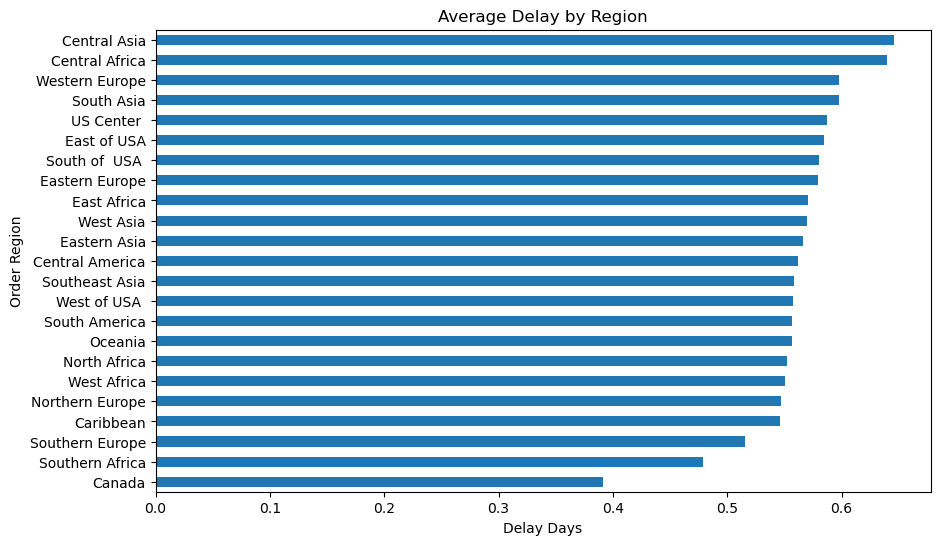

In [44]:
region_delay = df.groupby('Order Region')['Delay_Days'].mean().sort_values()

region_delay.plot(kind='barh', figsize=(10,6))
plt.title('Average Delay by Region')
plt.xlabel('Delay Days')
plt.show()

Top 10 categories with highest delay

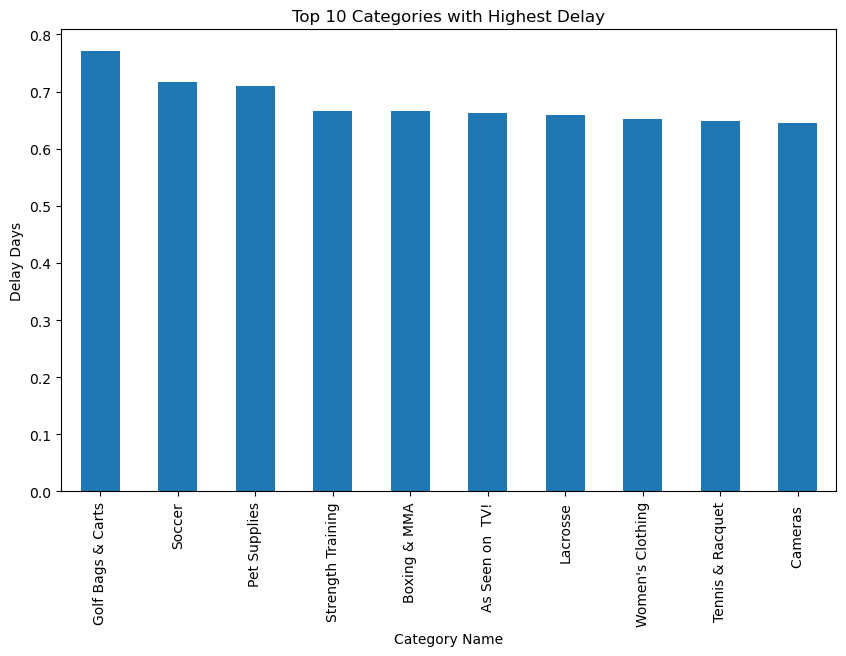

In [45]:
category_delay = df.groupby('Category Name')['Delay_Days'].mean()

category_delay.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Top 10 Categories with Highest Delay')
plt.ylabel('Delay Days')
plt.show()

Shipping Mode Performance

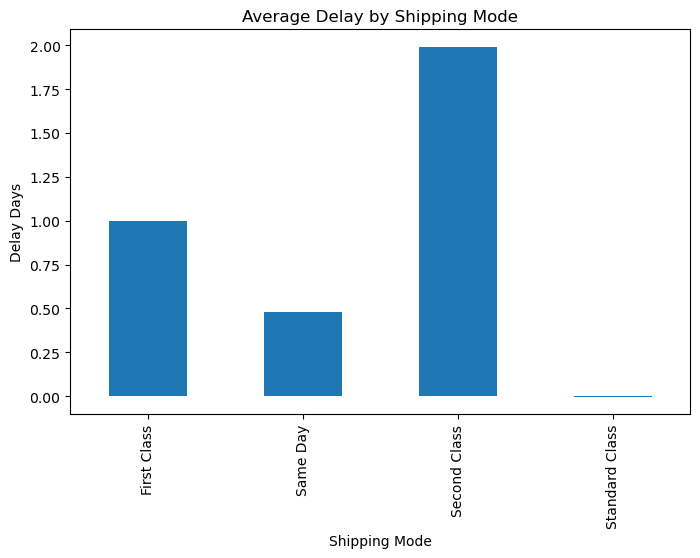

In [46]:
shipping_delay = df.groupby('Shipping Mode')['Delay_Days'].mean()

shipping_delay.plot(kind='bar', figsize=(8,5))
plt.title('Average Delay by Shipping Mode')
plt.ylabel('Delay Days')
plt.show()

Monthly Delay trend

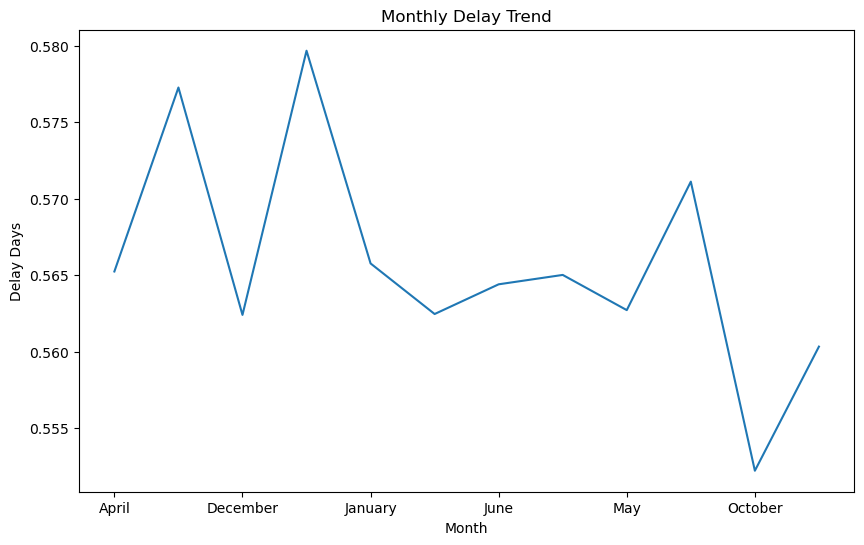

In [54]:
monthly_delay = df.groupby('Month')['Delay_Days'].mean()

monthly_delay.plot(kind='line', figsize=(10,6))
plt.title('Monthly Delay Trend')
plt.ylabel('Delay Days')
plt.show()

Sales by Category

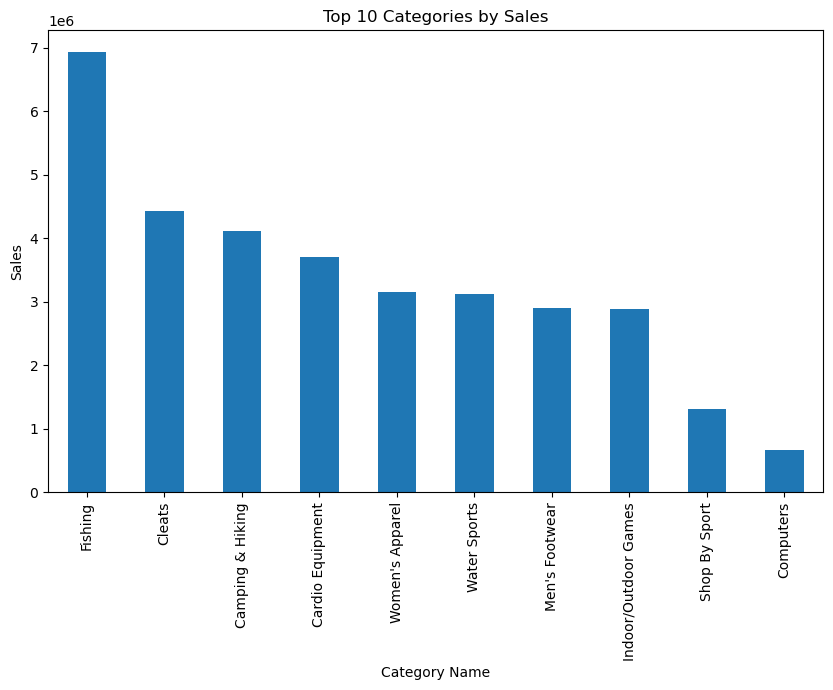

In [48]:
top_sales = df.groupby('Category Name')['Sales'].sum()

top_sales.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Top 10 Categories by Sales')
plt.ylabel('Sales')
plt.show()

Delivery Status distribution 

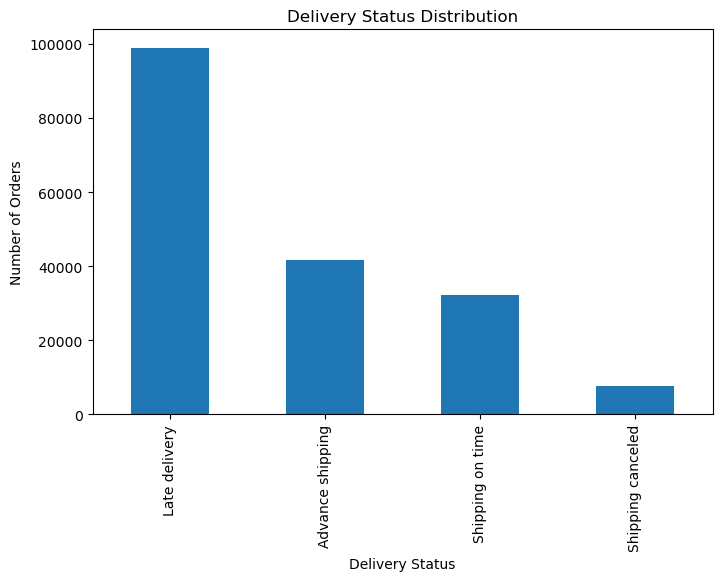

In [49]:
df['Delivery Status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.show()